In [150]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [151]:
dados = pd.read_csv(r'C:\Users\ashto\OneDrive\Documents\Python_\Cálculo_Numérico\Grupo02 (1).csv', sep =';')
dados['Precipitação'] = dados['Precipitação'].str.replace(',','.').astype(float)
dados

,Mês,Precipitação
0,1,144.4
1,2,150.0
2,3,125.8
3,4,94.0
4,5,111.0
5,6,262.2
6,7,149.8
7,8,186.0
8,9,188.4
9,10,231.3


Text(0.5, 1.0, 'Precipitação Mensal em [Nome da Cidade/Região] ao longo de 5 anos')

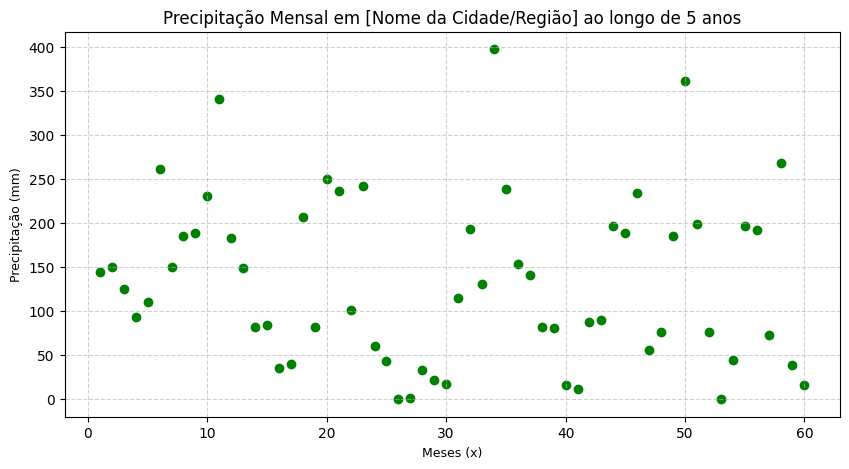

In [236]:
x_dados = dados['Mês']
y_dados = dados['Precipitação']

plt.figure(figsize = (10,5))
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.scatter(x_dados, y_dados, color ='green')
plt.ylabel('Precipitação (mm)', fontsize = 9)
plt.xlabel('Meses (x)', fontsize = 9)
plt.title('Precipitação Mensal em [Nome da Cidade/Região] ao longo de 5 anos', fontsize = 12)

In [153]:
# x => mês
# A0, A1, B1 coeficientes

def modelo_trigonometrico(x, A0, A1, B1):
    """
    período fixo em 12 meses
    """
    
    return A0 + A1*np.cos(2*np.pi * x /12) + B1 *np.sin(2*np.pi *x /12)


# curve_fit usa o metodo dos minimos quadrados para encontrar os melhores coeficientes A0, A1, B1
# `popt` conterá os coeficientes ótimos [A0, A1, B1]
# `pcov` é a matriz de covariância, que pode ser usada para calcular a incerteza dos parâmetros.
params_otimos, pcov = curve_fit(modelo_trigonometrico, x_dados, y_dados)

A0_fit, A1_fit, B1_fit = params_otimos
print("--- Coeficientes Encontrados ---")
print(f"A0 (Média de precipitação ajustada): {A0_fit:.2f}")
print(f"A1 (Coeficiente do cosseno): {A1_fit:.2f}")
print(f"B1 (Coeficiente do seno): {B1_fit:.2f}")
print("\nFunção final F(x) = {:.2f} + {:.2f}*cos(2*pi*x/12) + {:.2f}*sin(2*pi*x/12)".format(A0_fit, A1_fit, B1_fit))

--- Coeficientes Encontrados ---
A0 (Média de precipitação ajustada): 133.36
A1 (Coeficiente do cosseno): 28.24
B1 (Coeficiente do seno): -60.72

Função final F(x) = 133.36 + 28.24*cos(2*pi*x/12) + -60.72*sin(2*pi*x/12)



--- Previsão ---
A precipitação estimada para o mês 72 é: 161.60 mm


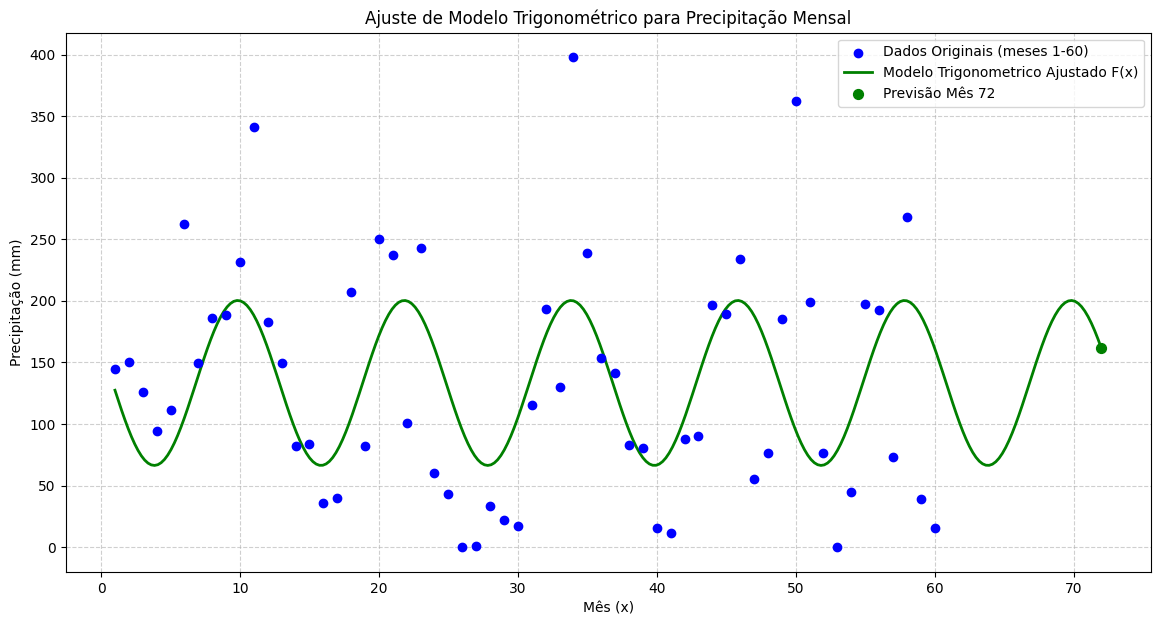

In [154]:
#visualizar

x_curva = np.linspace(1,72,300)
y_curva = modelo_trigonometrico(x_curva, *params_otimos) # * para desempacotar

plt.figure(figsize=(14,7))
plt.scatter(x_dados,y_dados,label='Dados Originais (meses 1-60)', color = 'blue', zorder=5)
plt.plot(x_curva,y_curva, label='Modelo Trigonometrico Ajustado F(x)', color ='green', linewidth = 2)

plt.title('Ajuste de Modelo Trigonométrico para Precipitação Mensal')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

mes_futuro = 72
precipitacao_prevista = modelo_trigonometrico(mes_futuro,*params_otimos)
print(f"\n--- Previsão ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=200, label=f'Previsão Mês {mes_futuro}', zorder=10)
plt.legend()
plt.show()

--- Previsão para o Mês 72 (para cada ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm


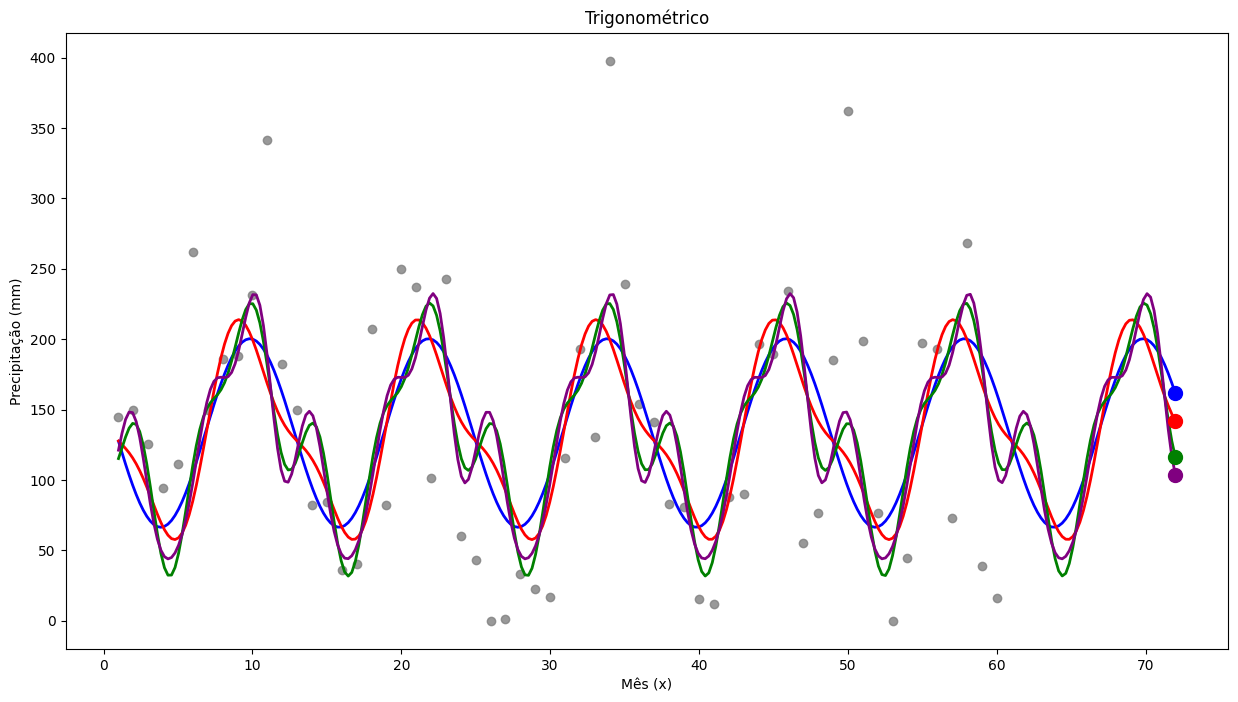

In [155]:
m = len(x_dados)

# --- A Função de Modelo Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        termo_cos = Ak * np.cos(2 * np.pi * ordem_k * x / 12)
        termo_sin = Bk * np.sin(2 * np.pi * ordem_k * x / 12)
        y = y + termo_cos + termo_sin
    return y

# --- Loop para Testar Ordens e Mostrar Previsões ---
plt.figure(figsize=(15, 8))
plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.8)

print("--- Previsão para o Mês 72 (para cada ordem) ---")

# Lista de cores para as curvas e pontos
cores = ['blue', 'red', 'green', 'purple']

for i, ordem_n in enumerate(range(1, 5)):
    num_params = 1 + 2 * ordem_n
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem_n)
    
    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Plotar a curva do modelo
        x_curva = np.linspace(1, 72, 300)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        cor_atual = cores[i % len(cores)] # Seleciona a cor
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem_n}', color=cor_atual, linewidth=2)
        
        # Calcular e mostrar a previsão para esta ordem
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem_n}: {precipitacao_prevista:.2f} mm")
        
        # Destacar o ponto da previsão no gráfico
        plt.scatter(mes_futuro, precipitacao_prevista, color=cor_atual, marker='o', s=100, zorder=10)

    except RuntimeError:
        print(f"Ordem {ordem_n}: Não foi possível ajustar o modelo.")

# --- Finalizar o gráfico ---
plt.title('Trigonométrico')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Interpolação polinomial -> não faz sentido pois explode

Ajustando um polinômio de grau 59...

--- Previsão com Interpolação Polinomial ---
A precipitação estimada para o mês 60 é: 1.569929e+01


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1179157907.py:23: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)


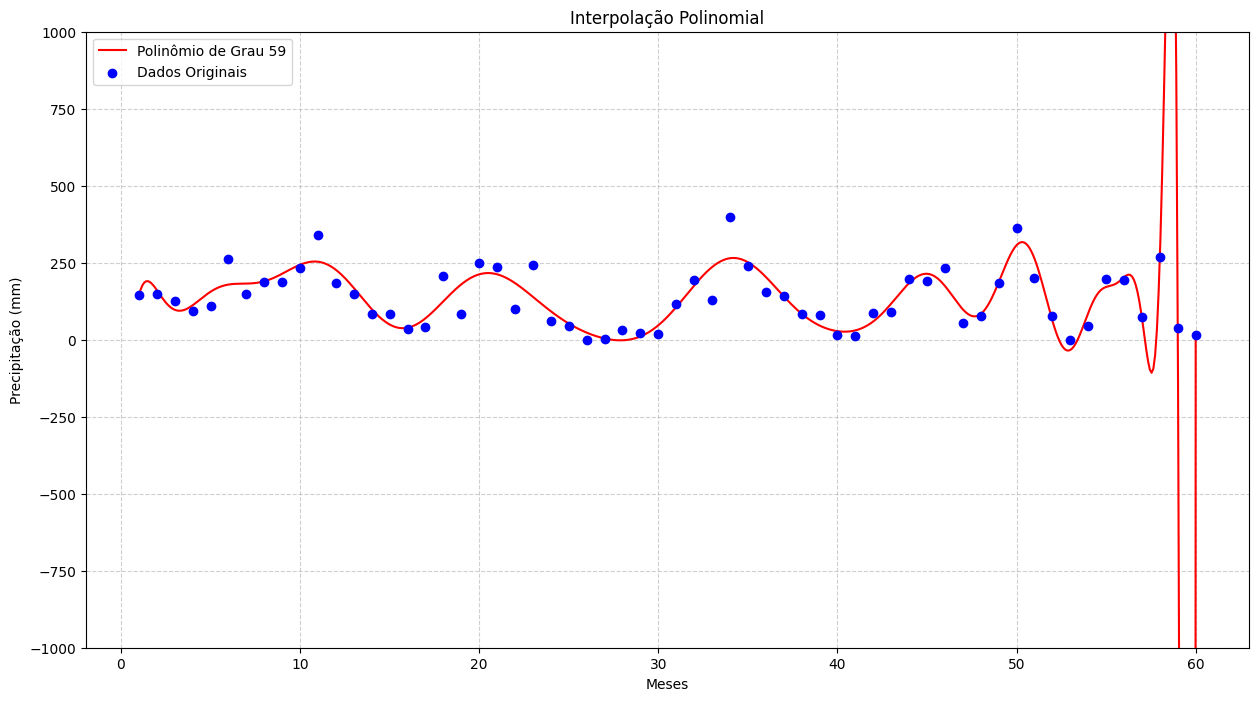

In [368]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Interpolação Polinomial ---
# Para 60 pontos, o grau do polinômio que passa por todos é 59.
grau_polinomio = 59

print(f"Ajustando um polinômio de grau {grau_polinomio}...")

# 1. Encontrar os coeficientes do polinômio
# A função pode emitir um aviso "Polyfit may be poorly conditioned", o que é esperado.
coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)

# 2. Criar a função polinomial a partir dos coeficientes
polinomio_interpolador = np.poly1d(coeficientes)

# 3. Calcular a previsão para o mês 72
mes_futuro = 60
precipitacao_prevista = polinomio_interpolador(mes_futuro)

print(f"\n--- Previsão com Interpolação Polinomial ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}") # Usando notação científica

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 60, 600)
y_curva = polinomio_interpolador(x_curva)
plt.plot(x_curva, y_curva, label=f'Polinômio de Grau {grau_polinomio}', color='red')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)

# ATENÇÃO: Vamos limitar o eixo Y para podermos ver os dados originais.
# A curva polinomial "explode" para valores muito altos/baixos.
plt.ylim(-1000, 1000) # Ajuste este limite para conseguir ver a curva vs. os pontos
plt.legend()
plt.show()

Ajustando um polinômio de grau 59...

--- Previsão com Interpolação Polinomial ---
A precipitação estimada para o mês 72 é: 1.085978e+15
ATENÇÃO: Este valor de previsão NÃO é confiável devido às oscilações extremas do polinômio.


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1321602662.py:24: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)


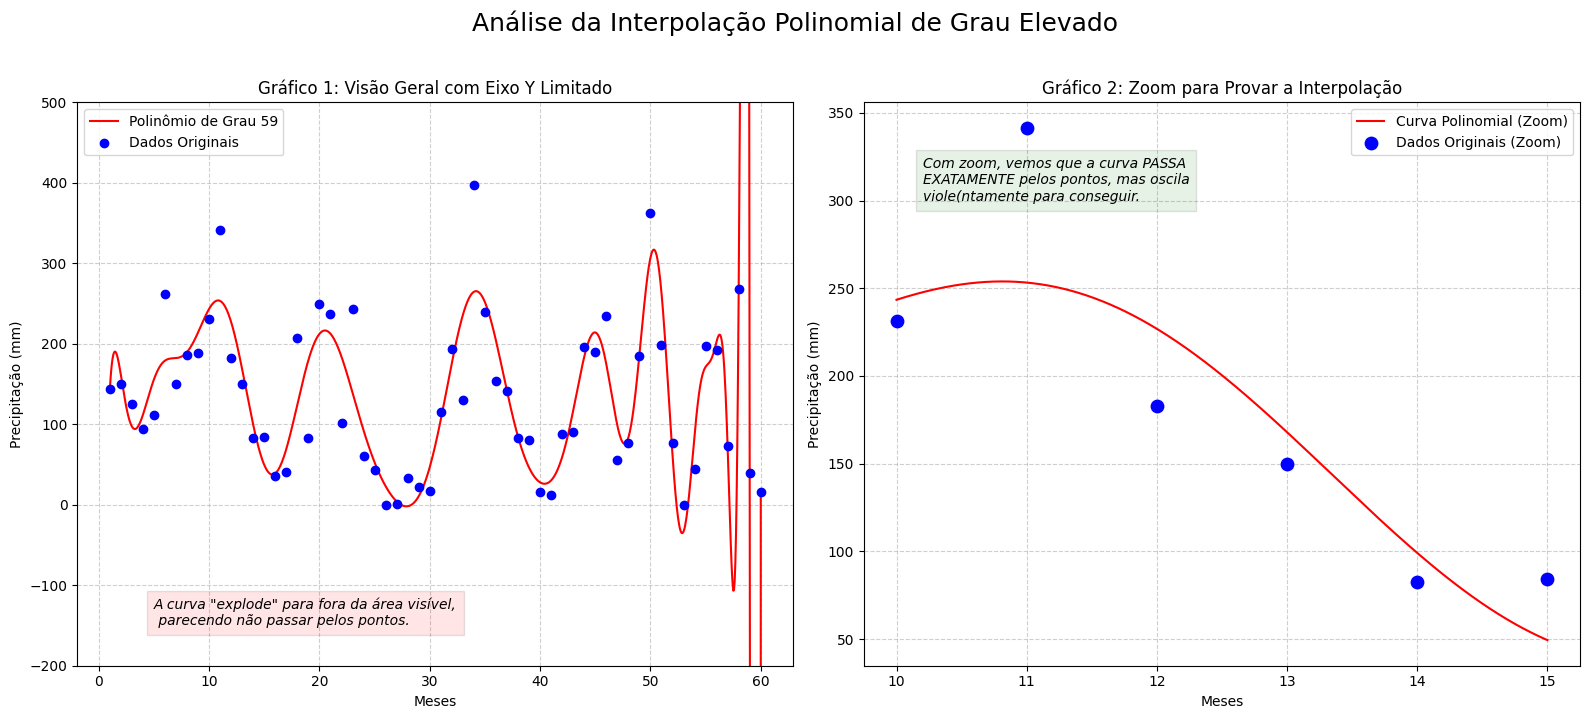


--- Conclusão ---
Como visto no Gráfico 2, o polinômio de fato passa por todos os pontos.
No entanto, as oscilações extremas (Fenômeno de Runge) o tornam inútil para visualização geral e previsão.
Para 'ligar os pontos' de forma suave, a melhor técnica é a Interpolação por Spline.


In [369]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Interpolação Polinomial (Grau 59) ---
# O grau DEVE ser N-1 para passar por N pontos.
grau_polinomio = len(x_dados) - 1

print(f"Ajustando um polinômio de grau {grau_polinomio}...")

# 1. Encontrar os coeficientes do polinômio.
# O aviso "Polyfit may be poorly conditioned" é esperado e confirma que o problema
# é numericamente instável, exatamente o que causa as oscilações.
coeficientes = np.polyfit(x_dados, y_dados, grau_polinomio)

# 2. Criar a função polinomial a partir dos coeficientes.
polinomio_interpolador = np.poly1d(coeficientes)

# 3. Calcular a previsão para o mês 72.
mes_futuro = 72
precipitacao_prevista = polinomio_interpolador(mes_futuro)

print("\n--- Previsão com Interpolação Polinomial ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")
print("ATENÇÃO: Este valor de previsão NÃO é confiável devido às oscilações extremas do polinômio.")

# --- GRÁFICO 1: VISÃO GERAL (O PROBLEMA) ---
plt.figure(figsize=(16, 7))
plt.suptitle('Análise da Interpolação Polinomial de Grau Elevado', fontsize=18, y=1.02)

plt.subplot(1, 2, 1)
# Gerar pontos para a curva para uma visualização mais detalhada
x_curva = np.linspace(x_dados.min(), x_dados.max(), 1000)
y_curva = polinomio_interpolador(x_curva)

plt.plot(x_curva, y_curva, label=f'Polinômio de Grau {grau_polinomio}', color='red')
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Gráfico 1: Visão Geral com Eixo Y Limitado')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
# Limitamos o eixo Y para conseguir ver os pontos.
# Isso esconde o fato de que a curva vermelha vai para valores absurdamente altos e baixos.
plt.ylim(-200, 500)
plt.legend()
plt.text(5, -150, 'A curva "explode" para fora da área visível,\n parecendo não passar pelos pontos.',
         style='italic', bbox={'facecolor': 'red', 'alpha': 0.1, 'pad': 5})


# --- GRÁFICO 2: VISÃO COM ZOOM (A PROVA) ---
plt.subplot(1, 2, 2)
# Vamos dar zoom em uma pequena seção dos dados, por exemplo, entre os meses 10 e 15
limite_x_zoom = (10, 15)

# Gerar pontos da curva apenas na seção com zoom para ver os detalhes
x_zoom = np.linspace(limite_x_zoom[0], limite_x_zoom[1], 500)
y_zoom = polinomio_interpolador(x_zoom)

# Plotar a curva interpolada na seção com zoom
plt.plot(x_zoom, y_zoom, label='Curva Polinomial (Zoom)', color='red', marker='None', zorder=10)

# Plotar os dados originais que estão dentro da nossa janela de zoom
idx_zoom = (x_dados >= limite_x_zoom[0]) & (x_dados <= limite_x_zoom[1])
plt.scatter(x_dados[idx_zoom], y_dados[idx_zoom], label='Dados Originais (Zoom)', color='blue', s=80, zorder=5)


plt.title('Gráfico 2: Zoom para Provar a Interpolação')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.text(10.2, 300, 'Com zoom, vemos que a curva PASSA\nEXATAMENTE pelos pontos, mas oscila\nviole(ntamente para conseguir.',
         style='italic', bbox={'facecolor': 'green', 'alpha': 0.1, 'pad': 5})

plt.tight_layout()
plt.show()

print("\n--- Conclusão ---")
print("Como visto no Gráfico 2, o polinômio de fato passa por todos os pontos.")
print("No entanto, as oscilações extremas (Fenômeno de Runge) o tornam inútil para visualização geral e previsão.")
print("Para 'ligar os pontos' de forma suave, a melhor técnica é a Interpolação por Spline.")



Lagrange => não faz sentido pois explode, obedece a todos os ruídos e, por isso, seu comportamento fora do intervalo dos dados é caótico e imprevisível.

Construindo o polinômio interpolador de Lagrange...

--- Previsão com Interpolação de Lagrange ---
A precipitação estimada para o mês 72 é: 9.090950e+39


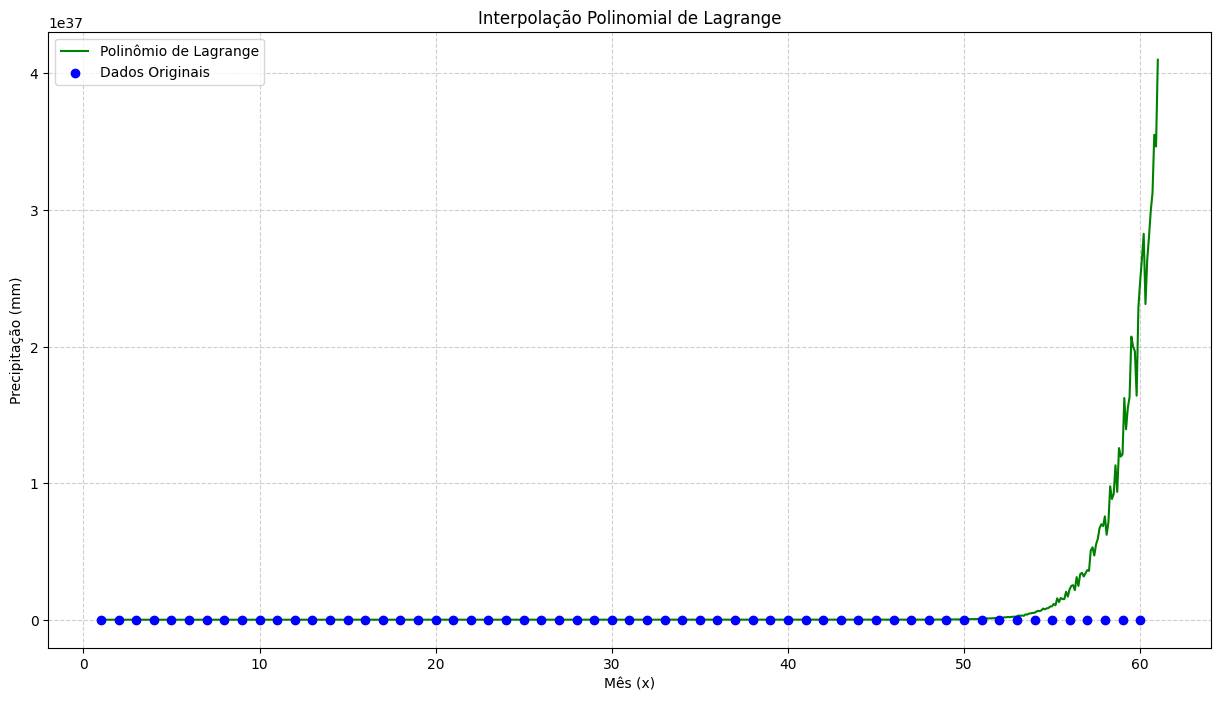

In [362]:
import numpy as np
from scipy.interpolate import lagrange
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Construindo o polinômio interpolador de Lagrange...")

# 1. A função lagrange já retorna o objeto de polinômio pronto para uso.
# É mais direto que o polyfit, que retorna apenas os coeficientes.
polinomio_lagrange = lagrange(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = polinomio_lagrange(mes_futuro)

print(f"\n--- Previsão com Interpolação de Lagrange ---")
# O resultado será idêntico ao do polyfit, pois o polinômio interpolador é único.
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
x_curva = np.linspace(1, 61, 600)
y_curva = polinomio_lagrange(x_curva)
plt.plot(x_curva, y_curva, label='Polinômio de Lagrange', color='green')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)

plt.title('Interpolação Polinomial de Lagrange')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.ylim(-200, 500) # Limitando o eixo Y para visualizar os dados
plt.legend()
# plt.ylim(-100, 400)
plt.show()

Interpolação linear => Não faz sentido pois simplesmente conecta pontos de dados consecutivos com uma linha reta. O resultado não é uma única curva suave, mas uma série de segmentos de retas

Criando a função de interpolação linear...

--- Previsão com Interpolação Linear ---
A precipitação estimada para o mês 72 é: -262.60 mm


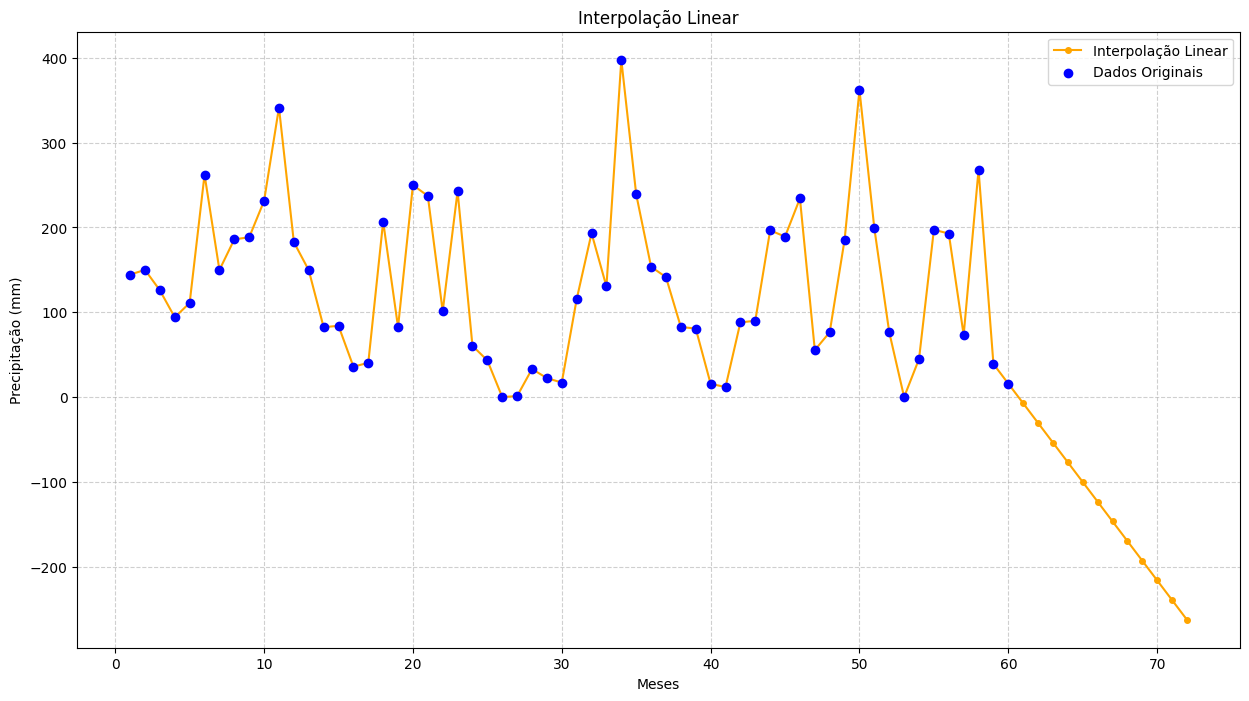

In [158]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

print("Criando a função de interpolação linear...")

# 1. Criar a função de interpolação
# 'kind='linear'' é o padrão, mas deixamos explícito.
# 'fill_value="extrapolate"' permite que a função faça previsões fora do intervalo [1, 60].
funcao_linear = interp1d(x_dados, y_dados, kind='linear', fill_value="extrapolate")

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = funcao_linear(mes_futuro)

print(f"\n--- Previsão com Interpolação Linear ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Plotar a curva interpolada
# Usamos os dados originais para x para mostrar os segmentos de reta
x_curva = np.arange(1, 73) # Vai até o mês 72
y_curva = funcao_linear(x_curva)
plt.plot(x_curva, y_curva, label='Interpolação Linear', color='orange', marker='o', markersize=4)

# Plotar os dados originais
plt.scatter(x_dados, y_dados, color='blue', zorder=5, label='Dados Originais')

plt.title('Interpolação Linear')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Diferenças divididas => não faz sentido pois tambem explode, é uma aproximação exata


 O seu objetivo é a aproximação e extrapolação – encontrar uma tendência geral em dados "ruidosos" e prever o futuro. São objetivos conflitantes.

Calculando o polinômio...


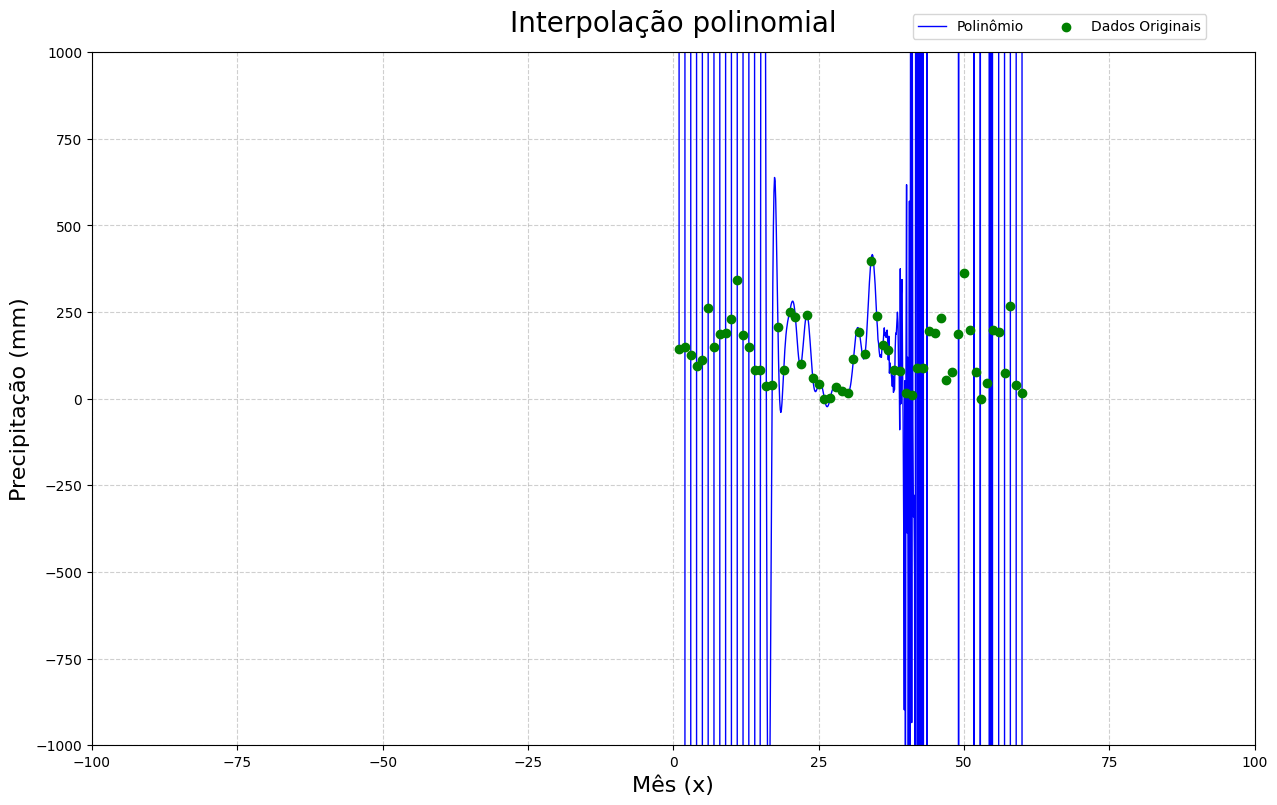

diferença x=37 e x=38 12.00995881732571
diferença x=38 e x=39 166.8185215150526
diferença x=39 e x=40 -515.950709873608
diferença x=40 e x=41 403.61552361554936
diferença x=41 e x=42 -2170.4522275389663
diferença x=42 e x=43 -4120.131666109741
diferença x=43 e x=44 -2518.9921528472732
diferença x=44 e x=45 -180023.49798708846
diferença x=45 e x=46 -997132.2119403761
diferença x=46 e x=47 -125357.45816468028
diferença x=47 e x=48 -6602400.915491793
diferença x=48 e x=49 -4149545.3456123034
diferença x=49 e x=50 -69724884.48094097
diferença x=50 e x=51 -10776538.083195731
diferença x=51 e x=52 -397271521.4861958
diferença x=52 e x=53 133013074.77959812
diferença x=53 e x=54 -3812895330.5168285
diferença x=54 e x=55 497641388.8451438
diferença x=55 e x=56 4577242781.752392
diferença x=56 e x=57 -65489229173.69531
diferença x=57 e x=58 -27130730076.573586
diferença x=58 e x=59 219118291643.37988
diferença x=59 e x=60 1909051751107.993
diferença x=60 e x=61 1.6375422244148945e+19


In [357]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados (sem alterações) ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Funções (sem alterações) ---
def calcular_coeficientes(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
    return coef[0, :]

def avaliar_polinomio(coef, x_data, x_eval):
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

# --- Lógica do Polinômio (sem alterações) ---
print("Calculando o polinômio...")
coeficientes_newton = calcular_coeficientes(x_dados, y_dados)


# --- Visualização com a Legenda Ajustada ---

# ALTERAÇÃO 1: Criamos 'fig' e 'ax' explicitamente
fig, ax = plt.subplots(figsize=(15, 9))

# Avaliar o polinômio em vários pontos para plotar a curva
x_curva = np.linspace(1,60,601)
# x_curva_2 = np.linspace(37, 60, 100)
# inteiros = np.arange(1,61)

# x_curva = np.hstack((x_curva, x_curva_2,inteiros))
# x_curva = np.sort(x_curva)
y_curva =[]
for x in x_curva:
    tempo = avaliar_polinomio(coeficientes_newton, x_dados, x)
    y_curva.append(tempo)
    # if tempo > 450 or tempo < -100:
    #     y_curva.append(450)
    # else:
    #     y_curva.append(tempo)

# ALTERAÇÃO 2: Usamos 'ax' para plotar, em vez de 'plt'
ax.plot(x_curva, y_curva, label='Polinômio', color='blue', linewidth = 1)
ax.scatter(x_dados, y_dados, label='Dados Originais', color='green', zorder=5)

# ALTERAÇÃO 3: Usamos 'ax.set_title', 'ax.set_xlabel', etc.
ax.set_title('Interpolação polinomial', fontsize=20, pad = 15) # 'pad' adiciona espaço para a legenda
ax.set_xlabel('Mês (x)', fontsize = 16)
ax.set_ylabel('Precipitação (mm)', fontsize = 16)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(-1000, 1000)
ax.set_xlim(-100,100)

# ALTERAÇÃO 4 (A PRINCIPAL): Usamos fig.legend() para colocar a legenda fora do gráfico
# Primeiro, pegamos os "handles" e "labels" do nosso gráfico 'ax'
handles, labels = ax.get_legend_handles_labels()

# Agora, criamos a legenda para a FIGURA, posicionando-a no topo
# bbox_to_anchor=(x, y) com y próximo a 1 coloca a legenda no topo.
# ncol=2 deixa a legenda na horizontal.
fig.legend(
    handles, 
    labels,
    loc='upper center',          # Ancora a legenda pelo seu topo e centro
    bbox_to_anchor=(0.77, 0.93),  # Posiciona no meio horizontal (0.5) e no topo (0.95) da figura
    ncol=2,                      # Número de colunas da legenda
    fontsize=10
)

# Para posicionar à direita do título, você poderia usar:
# fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.9, 0.95), fontsize=12)

# Para posicionar à esquerda do título:
# fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.1, 0.95), fontsize=12)


plt.show()

for i in range(37,61):
    print(f'diferença x={i} e x={i+1} {avaliar_polinomio(coeficientes_newton, x_dados, i+1)-avaliar_polinomio(coeficientes_newton, x_dados, i)}')

In [311]:
x_curva = np.linspace(1, 10, 102)
inte = np.arange(1,10)
# todos = x_curva + inte
todos = np.hstack((x_curva, inte))
# print(inte)
# print(x_curva)
print(todos)

[ 1.          1.08910891  1.17821782  1.26732673  1.35643564  1.44554455
  1.53465347  1.62376238  1.71287129  1.8019802   1.89108911  1.98019802
  2.06930693  2.15841584  2.24752475  2.33663366  2.42574257  2.51485149
  2.6039604   2.69306931  2.78217822  2.87128713  2.96039604  3.04950495
  3.13861386  3.22772277  3.31683168  3.40594059  3.4950495   3.58415842
  3.67326733  3.76237624  3.85148515  3.94059406  4.02970297  4.11881188
  4.20792079  4.2970297   4.38613861  4.47524752  4.56435644  4.65346535
  4.74257426  4.83168317  4.92079208  5.00990099  5.0990099   5.18811881
  5.27722772  5.36633663  5.45544554  5.54455446  5.63366337  5.72277228
  5.81188119  5.9009901   5.99009901  6.07920792  6.16831683  6.25742574
  6.34653465  6.43564356  6.52475248  6.61386139  6.7029703   6.79207921
  6.88118812  6.97029703  7.05940594  7.14851485  7.23762376  7.32673267
  7.41584158  7.5049505   7.59405941  7.68316832  7.77227723  7.86138614
  7.95049505  8.03960396  8.12871287  8.21782178  8

Calculando o polinômio via Diferenças Divididas de Newton...

--- Previsão com Diferenças Divididas de Newton ---
A precipitação estimada para o mês 72 é: 2.957245e+31


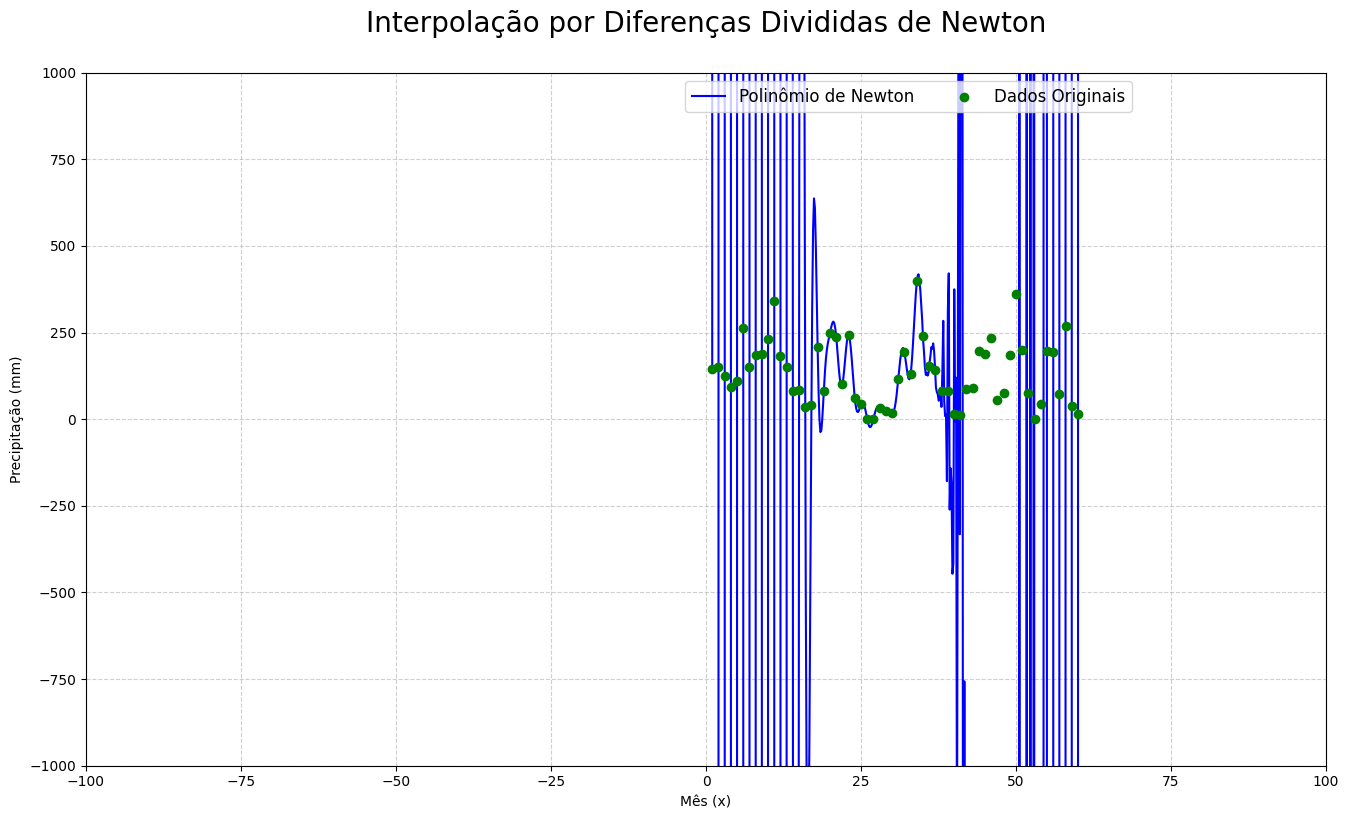

In [359]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Implementação do Método de Diferenças Divididas de Newton ---

def calcular_coeficientes(x, y):
    """
    Calcula os coeficientes (a diagonal da tabela de diferenças divididas).
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y # A primeira coluna é y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Retorna a primeira linha (c0, c1, c2, ...)

def avaliar_polinomio(coef, x_data, x_eval):
    """
    Avalia o polinômio na forma de Newton em um ponto x_eval.
    """
    n = len(coef) - 1
    p = coef[n]
    for k in range(1, n + 1):
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

print("Calculando o polinômio via Diferenças Divididas de Newton...")

# 1. Calcular os coeficientes c0, c1, ...
coeficientes_newton = calcular_coeficientes(x_dados, y_dados)

# 2. Calcular a previsão para o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_polinomio(coeficientes_newton, x_dados, mes_futuro)

print(f"\n--- Previsão com Diferenças Divididas de Newton ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# --- Visualização ---
plt.figure(figsize=(16, 9))

# Avaliar o polinômio em vários pontos para plotar a curva
x_curva = np.linspace(1, 60, 400) # Evitamos extrapolar no plot para não distorcer a escala
y_curva = [avaliar_polinomio(coeficientes_newton, x_dados, x) for x in x_curva]
plt.plot(x_curva, y_curva, label='Polinômio de Newton', color='blue')

# Plotar os dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='green', zorder=5)

plt.title('Interpolação por Diferenças Divididas de Newton\n', fontsize = 20)
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)

# Adiciona a legenda à figura, usando os elementos que criamos
plt.legend(
           loc='upper right',
           bbox_to_anchor=(0.85, 1.0), # Posição abaixo do título principal
           ncol=2,
           fontsize=12)

plt.ylim(-1000, 1000)
plt.xlim(-100,100)
plt.show()

Formula de Newton-> igual diferenças divididas

Executando o método de interpolação de Newton...

A previsão para o mês 72 é: 2.957245e+31


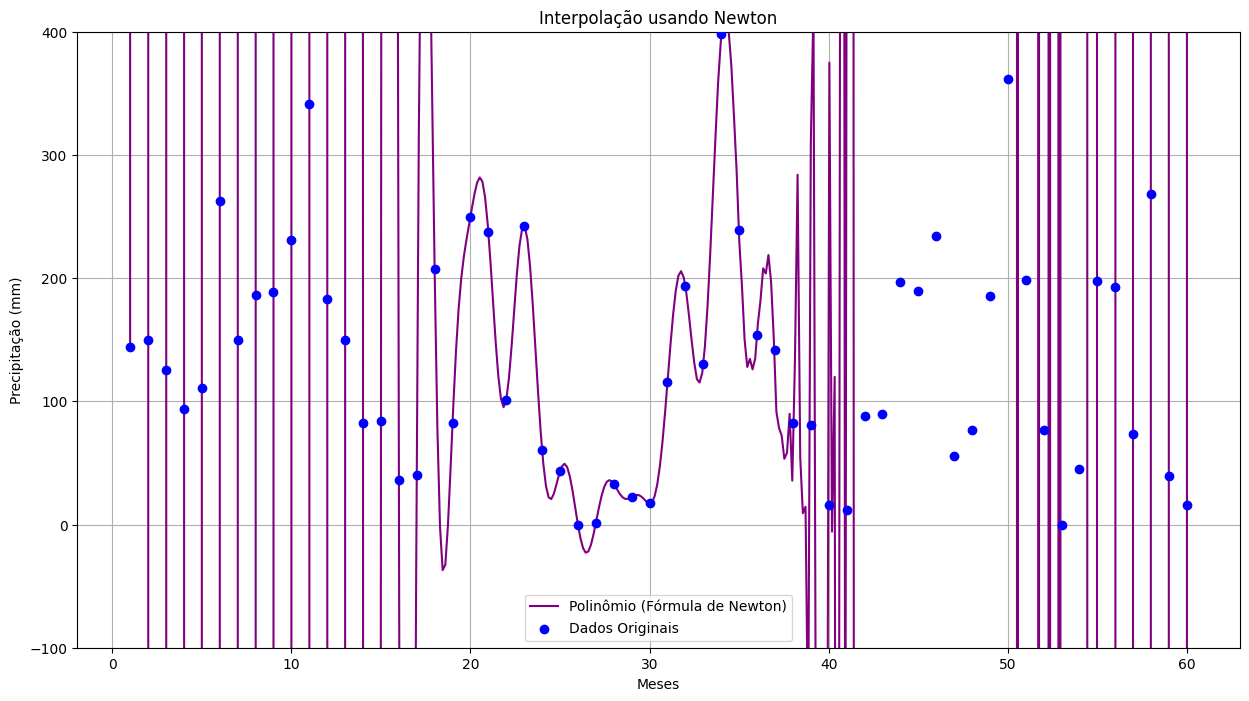

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# ==============================================================================
# PARTE 1: CALCULANDO OS "INGREDIENTES" (AS DIFERENÇAS DIVIDIDAS)
# ==============================================================================
def calcular_coeficientes_newton(x, y):
    """
    Esta função calcula os coeficientes c0, c1, c2, ... 
    que são as próprias diferenças divididas.
    """
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j] - x[i])
            
    return coef[0, :] # Os coeficientes são a primeira linha da tabela

# ==============================================================================
# PARTE 2: USANDO A "RECEITA" (A FÓRMULA DE NEWTON)
# ==============================================================================
def avaliar_com_formula_newton(coef, x_data, x_eval):
    """
    Esta função usa a Fórmula de Newton para montar o polinômio e calcular 
    seu valor em um ponto específico (x_eval), usando os coeficientes da Parte 1.
    P(x) = c0 + c1(x-x0) + c2(x-x0)(x-x1) + ...
    """
    n = len(coef) - 1
    p = coef[n] # Começa com o último coeficiente
    for k in range(1, n + 1):
        # Itera de trás para frente, construindo o polinômio
        p = coef[n - k] + (x_eval - x_data[n - k]) * p
    return p

# --- Executando o Processo Completo ---
print("Executando o método de interpolação de Newton...")

# 1. Obter os ingredientes (Diferenças Divididas)
coeficientes = calcular_coeficientes_newton(x_dados, y_dados)

# 2. Usar a receita (Fórmula de Newton) para prever o mês 72
mes_futuro = 72
precipitacao_prevista = avaliar_com_formula_newton(coeficientes, x_dados, mes_futuro)

print(f"\nA previsão para o mês {mes_futuro} é: {precipitacao_prevista:e}")

# 3. Usar a receita novamente para gerar o gráfico
x_curva = np.linspace(1, 60, 400)
y_curva = [avaliar_com_formula_newton(coeficientes, x_dados, x) for x in x_curva]

# --- Visualização ---
plt.figure(figsize=(15, 8))
plt.plot(x_curva, y_curva, label='Polinômio (Fórmula de Newton)', color='purple')
plt.scatter(x_dados, y_dados, label='Dados Originais', color='blue', zorder=5)
plt.title('Interpolação usando Newton')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True)
plt.legend()
plt.ylim(-100,400)
plt.show()

MMQ Caso polinomial =>  Inadequada por não conseguir modelar a sazonalidade

faz mais sentido usar a trigonometrica, pois podemos usar uma periódicidade

--- Previsões com MMQ Polinomial para o Mês 72 ---
Grau 1: 108.74 mm
Grau 2: 152.05 mm
Grau 3: 71.73 mm
Grau 4: -519.90 mm
Grau 10: -31924.69 mm


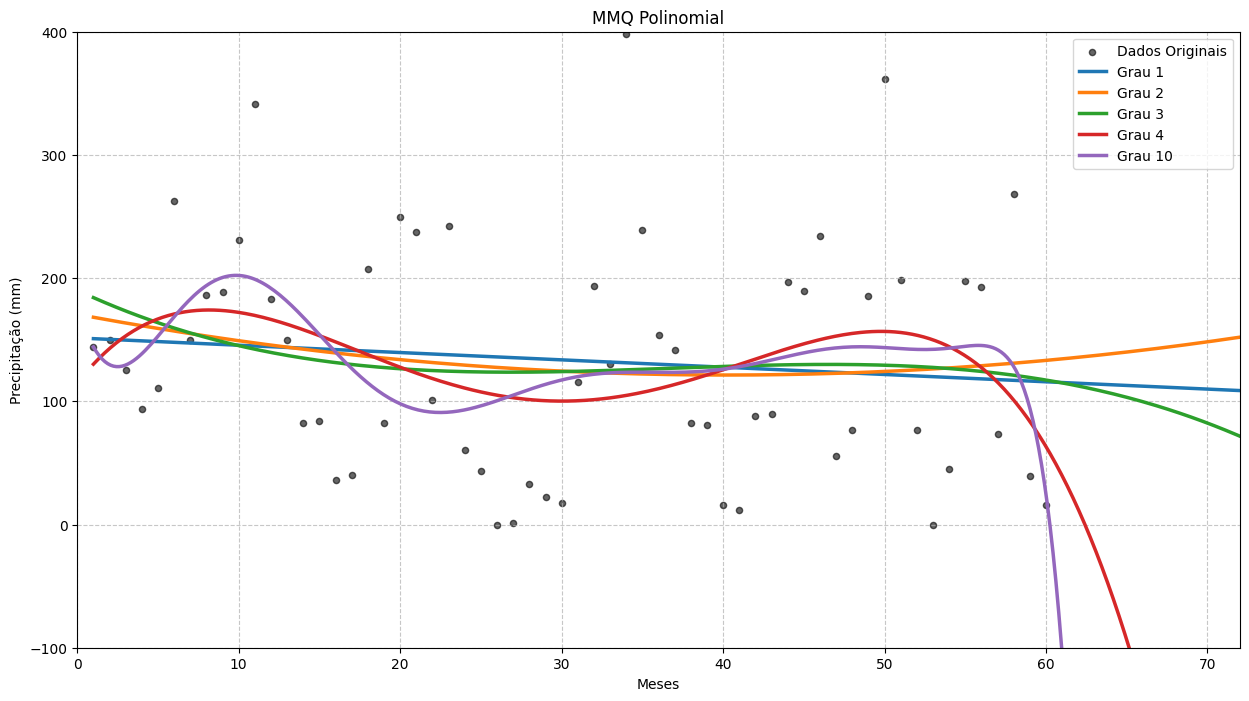

In [192]:
import numpy as np
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])


# --- Estrutura Principal do Gráfico Comparativo ---

# 1. Criar a figura e os eixos UMA VEZ
plt.figure(figsize=(15, 8))
# 2. Plotar os dados originais UMA VEZ
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', alpha=0.6, s=20)

print("--- Previsões com MMQ Polinomial para o Mês 72 ---")

# Vamos testar alguns graus baixos e um grau um pouco mais alto para ver o overfitting
graus_a_testar = [1, 2, 3, 4, 10] 

# 3. Loop para calcular e plotar cada modelo polinomial
for grau in graus_a_testar:
    
    # Ajustar o polinômio de grau baixo usando MMQ
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio_mmq = np.poly1d(coeficientes)
    
    # Gerar a curva de tendência
    x_curva = np.linspace(1, 72, 400)
    y_curva = polinomio_mmq(x_curva)
    
    # Plotar a curva do modelo atual no mesmo gráfico
    plt.plot(x_curva, y_curva, label=f'Grau {grau}', linewidth=2.5)
    
    # Calcular e imprimir a previsão
    mes_futuro = 72
    precipitacao_prevista = polinomio_mmq(mes_futuro)
    print(f"Grau {grau}: {precipitacao_prevista:.2f} mm")


# 4. Configurar os detalhes do gráfico DEPOIS do loop
plt.title('MMQ Polinomial')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.ylim(-100, 400)
plt.xlim(0,72)
plt.show()

In [162]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função que gera o gráfico com base no grau escolhido ---
def plotar_polinomio_por_grau(grau):
    """
    Esta função é chamada toda vez que você move o slider.
    Ela ajusta um polinômio do 'grau' especificado e plota o resultado.
    """
    
    # Prevenir avisos de instabilidade para graus muito altos
 
    # 1. Ajustar o polinômio (MMQ)
    coeficientes = np.polyfit(x_dados, y_dados, grau)
    polinomio_mmq = np.poly1d(coeficientes)
    
    # 2. Gerar a curva para o plot
    x_curva = np.linspace(1, 72, 400)
    y_curva = polinomio_mmq(x_curva)
    
    # 3. Fazer a previsão para o mês 72
    mes_futuro = 72
    precipitacao_prevista = polinomio_mmq(mes_futuro)
    
    # 4. Plotar tudo
    plt.figure(figsize=(14, 7))
    plt.scatter(x_dados, y_dados, label='Dados Originais', color='gray', alpha=0.7)
    plt.plot(x_curva, y_curva, label=f'Curva do Polinômio (Grau {grau})', color='red')
    
    plt.title(f'MMQ Polinomial de Grau {grau}')
    plt.xlabel('Mês (x)')
    plt.ylabel('Precipitação (mm)')
    
    # Adicionar o texto da previsão dentro do gráfico
    # Usamos try/except para o caso de a previsão ser um número enorme
    try:
        texto_previsao = f'Previsão Mês 72: {precipitacao_prevista:.2f} mm'
    except OverflowError:
        texto_previsao = 'Previsão Mês 72: Valor muito grande (explosão)'
        
    plt.text(5, 400, texto_previsao, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    # Limitamos o eixo Y para que o gráfico não "exploda" com graus altos
    plt.ylim(-150, 500)
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Criando a Interatividade ---
# O 'interact' cria um slider para o argumento 'grau' da nossa função
interact(plotar_polinomio_por_grau, 
         grau=widgets.IntSlider(value=2, min=0, max=59, step=1, description='Grau do Polinômio:'));

interactive(children=(IntSlider(value=2, description='Grau do Polinômio:', max=59), Output()), _dom_classes=('…

MMQ - trigonométrico => melhor opção

--- Previsões para o Mês 72 (por ordem) ---
Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm
Ordem 5: 88.10 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\28615503.py:42: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)


Ordem 6: 97.78 mm


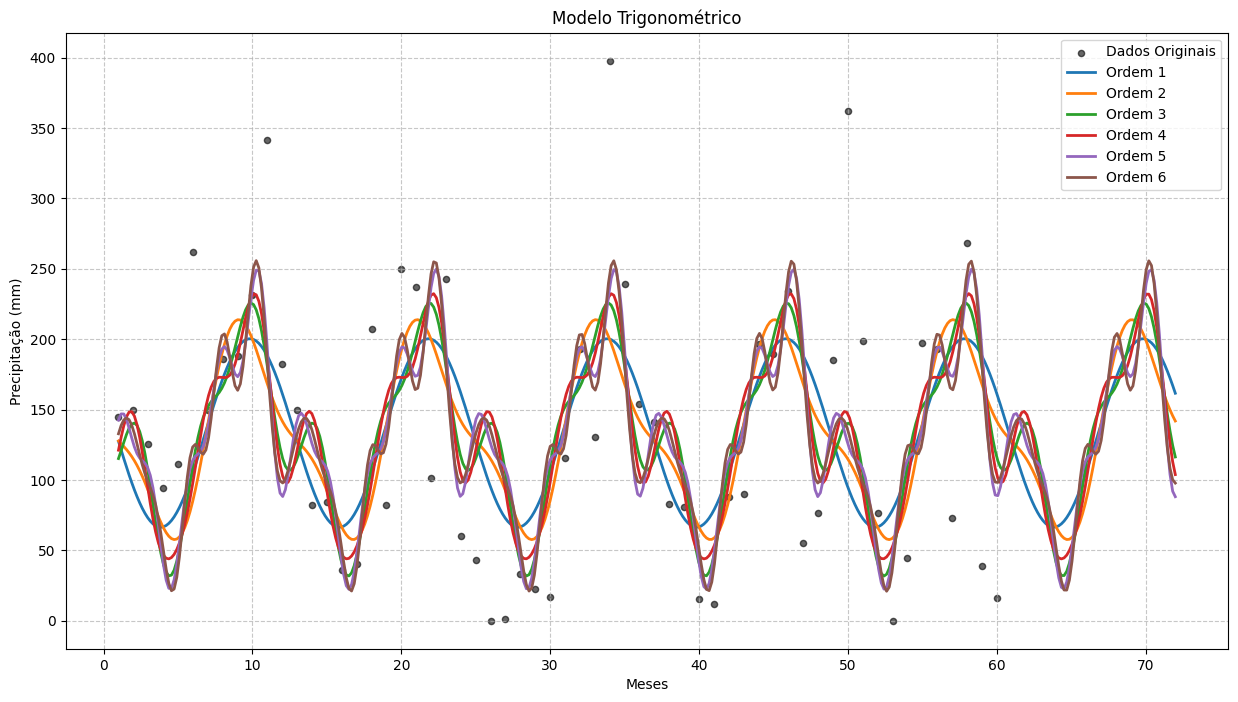

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico ---

# 1. Criar a figura e os eixos UMA VEZ, antes do loop
plt.figure(figsize=(15, 8))
# 2. Plotar os dados originais UMA VEZ
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', alpha=0.6, s=20)

print("--- Previsões para o Mês 72 (por ordem) ---")

# 3. Loop para calcular e plotar cada modelo
for ordem in range(1, 7): # De 1 a 6
    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        # Ajustar o modelo para a ordem atual
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Gerar a curva suave para o plot
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar a curva do modelo atual no mesmo gráfico
        plt.plot(x_curva, y_curva, label=f'Ordem {ordem}', linewidth=2)
        
        # Calcular e imprimir a previsão
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: {precipitacao_prevista:.2f} mm")

    except RuntimeError:
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 4. Configurar os detalhes do gráfico DEPOIS do loop
plt.title('Modelo Trigonométrico')
plt.xlabel('Meses')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.show()

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import ipywidgets as widgets
from ipywidgets import interact

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Função interativa que será controlada pelo slider ---
def plotar_trigonometrico_por_ordem(ordem):
    """
    Ajusta e plota o modelo trigonométrico para a 'ordem' escolhida no slider.
    """
    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Previsão para o mês 72
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        
        x_inteiro = np.arange(0,61)
        y_inteiro = modelo_trigonometrico_geral(x_inteiro, *params_otimos)
        
        
        # Plotagem
        plt.figure(figsize=(14, 7))
        plt.scatter(x_dados, y_dados, label='Dados Originais', color='green', alpha=0.7, s=15)
        plt.scatter(x_inteiro, y_inteiro, color='blue', zorder=2, s=15, label='Pontos para x inteiro')
        
        y_preditos_para_dados = modelo_trigonometrico_geral(x_dados, *params_otimos)
        
        # Itera sobre cada ponto para desenhar a linha de diferença
        for i in range(len(x_dados)):
            # Adiciona um rótulo apenas à primeira linha para não poluir a legenda
            label_residuo = 'Diferença (Resíduo)' if i == 0 else ""
            
            plt.plot(
                [x_dados[i], x_dados[i]],                      # Coordenadas X (início e fim)
                [y_dados[i], y_preditos_para_dados[i]],       # Coordenadas Y (início e fim)
                color='red',
                linestyle=':',  # Estilo pontilhado
                linewidth=1,
                alpha=0.8,
                label=label_residuo)
        
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        plt.plot(x_curva, y_curva, label=f'Modelo Trigonométrico (Ordem {ordem})', color='blue', alpha = 0.3)
        plt.plot(x_curva, y_curva+100, label=f'Modelo Trigonométrico (Ordem {ordem})', color='red', alpha = 0.3)
        
        plt.scatter(mes_futuro, precipitacao_prevista, color='green', marker='.', s=250, label=f'Previsão Mês 72:{precipitacao_prevista:.2f} mm', zorder=10)
        
        plt.title(f'MMQ Trigonométrico - Ordem {ordem}')
        plt.xlabel('Meses (x)')
        plt.ylabel('Precipitação (mm)')
        plt.grid(True)
        plt.legend(fontsize=10)
        plt.show()

    except RuntimeError:
        print(f"Não foi possível ajustar o modelo para a ordem {ordem}. Tente uma ordem menor.")

# --- Cria o slider para controlar a 'ordem' da função ---
# Limitamos a ordem máxima a 6, pois ordens maiores são fisicamente questionáveis (ver Limite de Nyquist)
interact(plotar_trigonometrico_por_ordem, 
         ordem=widgets.IntSlider(value=1, min=1, max=6, step=1, description='Ordem do Modelo:'));

interactive(children=(IntSlider(value=1, description='Ordem do Modelo:', max=6, min=1), Output()), _dom_classe…

Ordem 1: 161.60 mm
Ordem 2: 141.88 mm
Ordem 3: 116.34 mm
Ordem 4: 103.82 mm
Ordem 5: 88.10 mm
Ordem 6: 97.78 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\860585292.py:47: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\860585292.py:72: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  fig.legend(['dados originais'], ['modelo ajustado'])


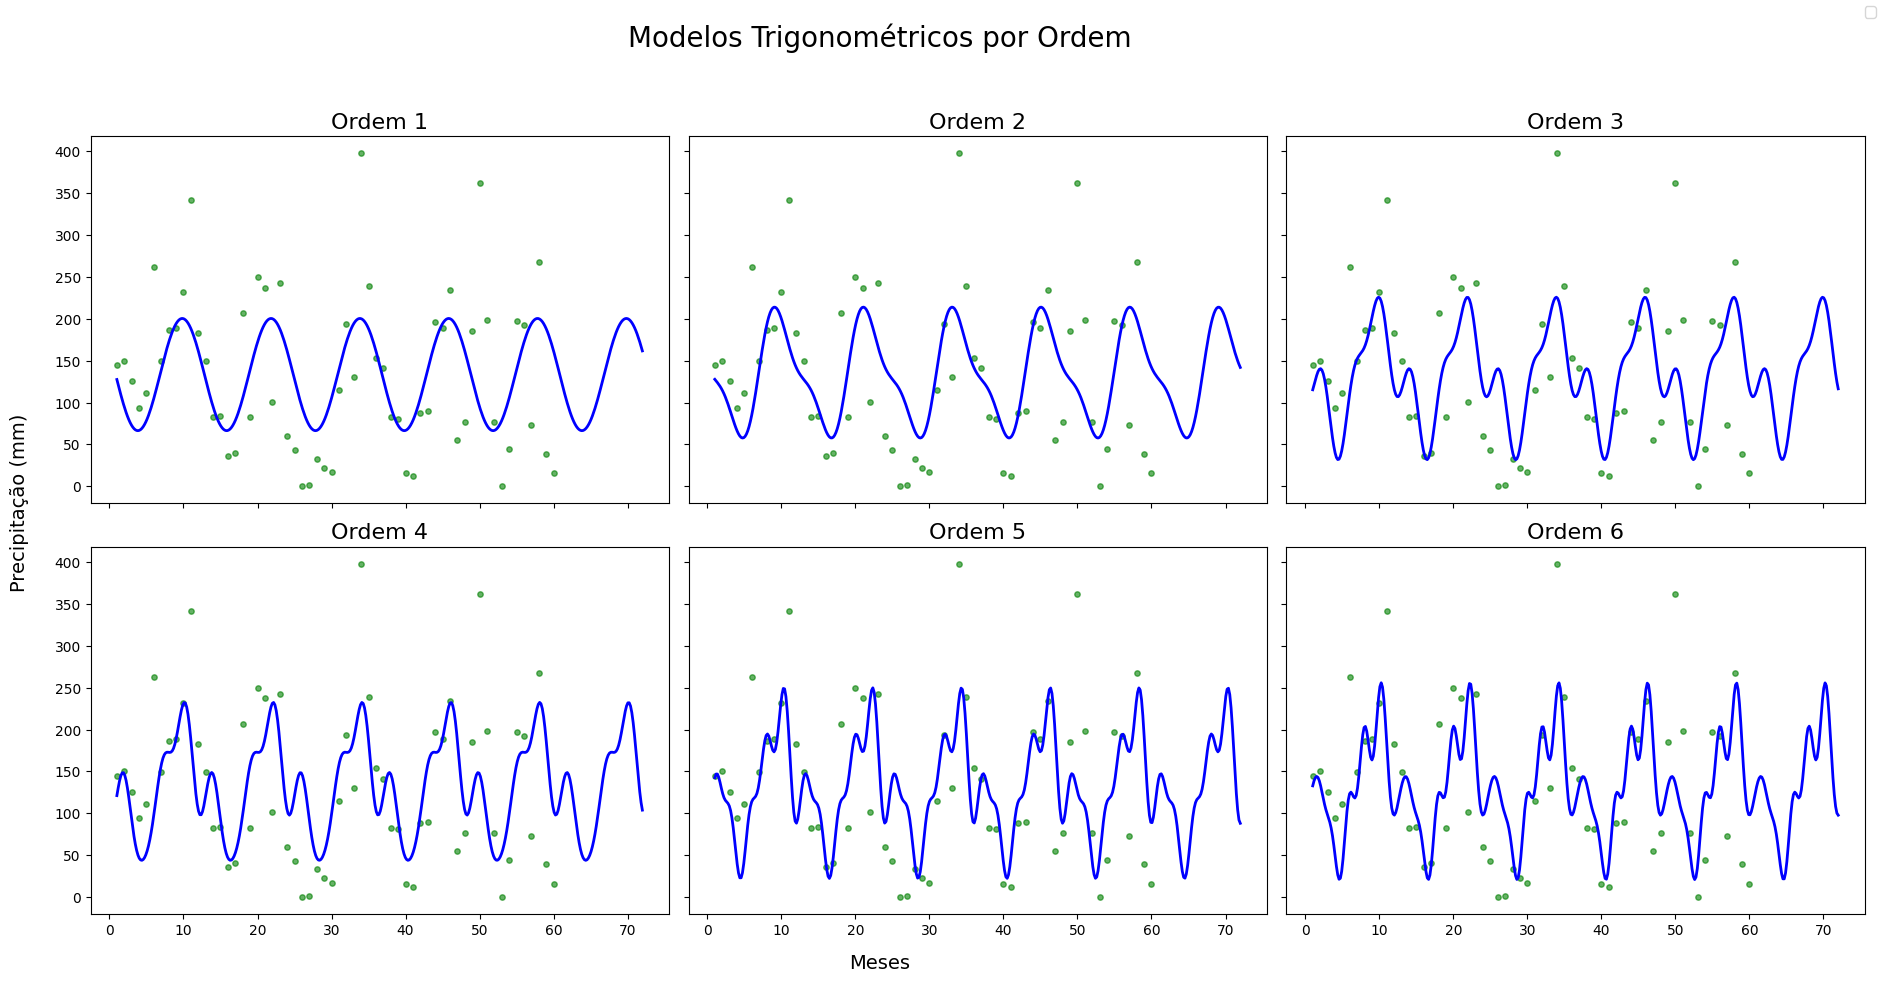

In [214]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico com Subplots ---

# 1. Criar uma figura e uma grade de eixos 2x3.
# `sharex=True` e `sharey=True` fazem com que todos os gráficos tenham a mesma escala.
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# Adicionar um título principal para a figura inteira
fig.suptitle('Modelos Trigonométricos por Ordem', fontsize=20)

# 2. Loop para preencher cada subplot
for ordem in range(1, 7): # De 1 a 6
    # Calcular a posição do subplot na grade (linha e coluna)
    row = (ordem - 1) // 3
    col = (ordem - 1) % 3
    ax = axs[row, col] # Seleciona o subplot atual

    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        # Ajustar o modelo para a ordem atual
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        
        # Gerar a curva suave para o plot
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar os dados e a curva NO SUBPLOT ATUAL (usando 'ax.')
        ax.scatter(x_dados, y_dados, color='green', alpha=0.6, s=15)
        ax.plot(x_curva, y_curva, color='blue', linewidth=2)
        
        
        # Calcular e imprimir a previsão
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: {precipitacao_prevista:.2f} mm")

        ax.set_title(f'Ordem {ordem}', fontsize=16)

    except RuntimeError:
        ax.set_title(f'Ordem {ordem} - Falha no Ajuste', color='red')
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 3. Adicionar rótulos comuns para a figura inteira
fig.text(0.5, 0.04, 'Meses', ha='center', va='center', fontsize=14)
fig.text(0.07, 0.5, 'Precipitação (mm)', ha='center', va='center', rotation='vertical', fontsize=14)
fig.legend(['dados originais'], ['modelo ajustado'])

# Ajustar o layout para evitar sobreposição
plt.tight_layout(rect=[0.08, 0.05, 1, 0.95]) # Ajusta a posição para dar espaço aos rótulos e título

plt.show()

Ordem 1: Previsão para o mês 72 = 161.60 mm
Ordem 2: Previsão para o mês 72 = 141.88 mm
Ordem 3: Previsão para o mês 72 = 116.34 mm
Ordem 4: Previsão para o mês 72 = 103.82 mm
Ordem 5: Previsão para o mês 72 = 88.10 mm
Ordem 6: Previsão para o mês 72 = 97.78 mm


C:\Users\ashto\AppData\Local\Temp\ipykernel_18492\1380445928.py:44: OptimizeWarning: Covariance of the parameters could not be estimated
  params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)


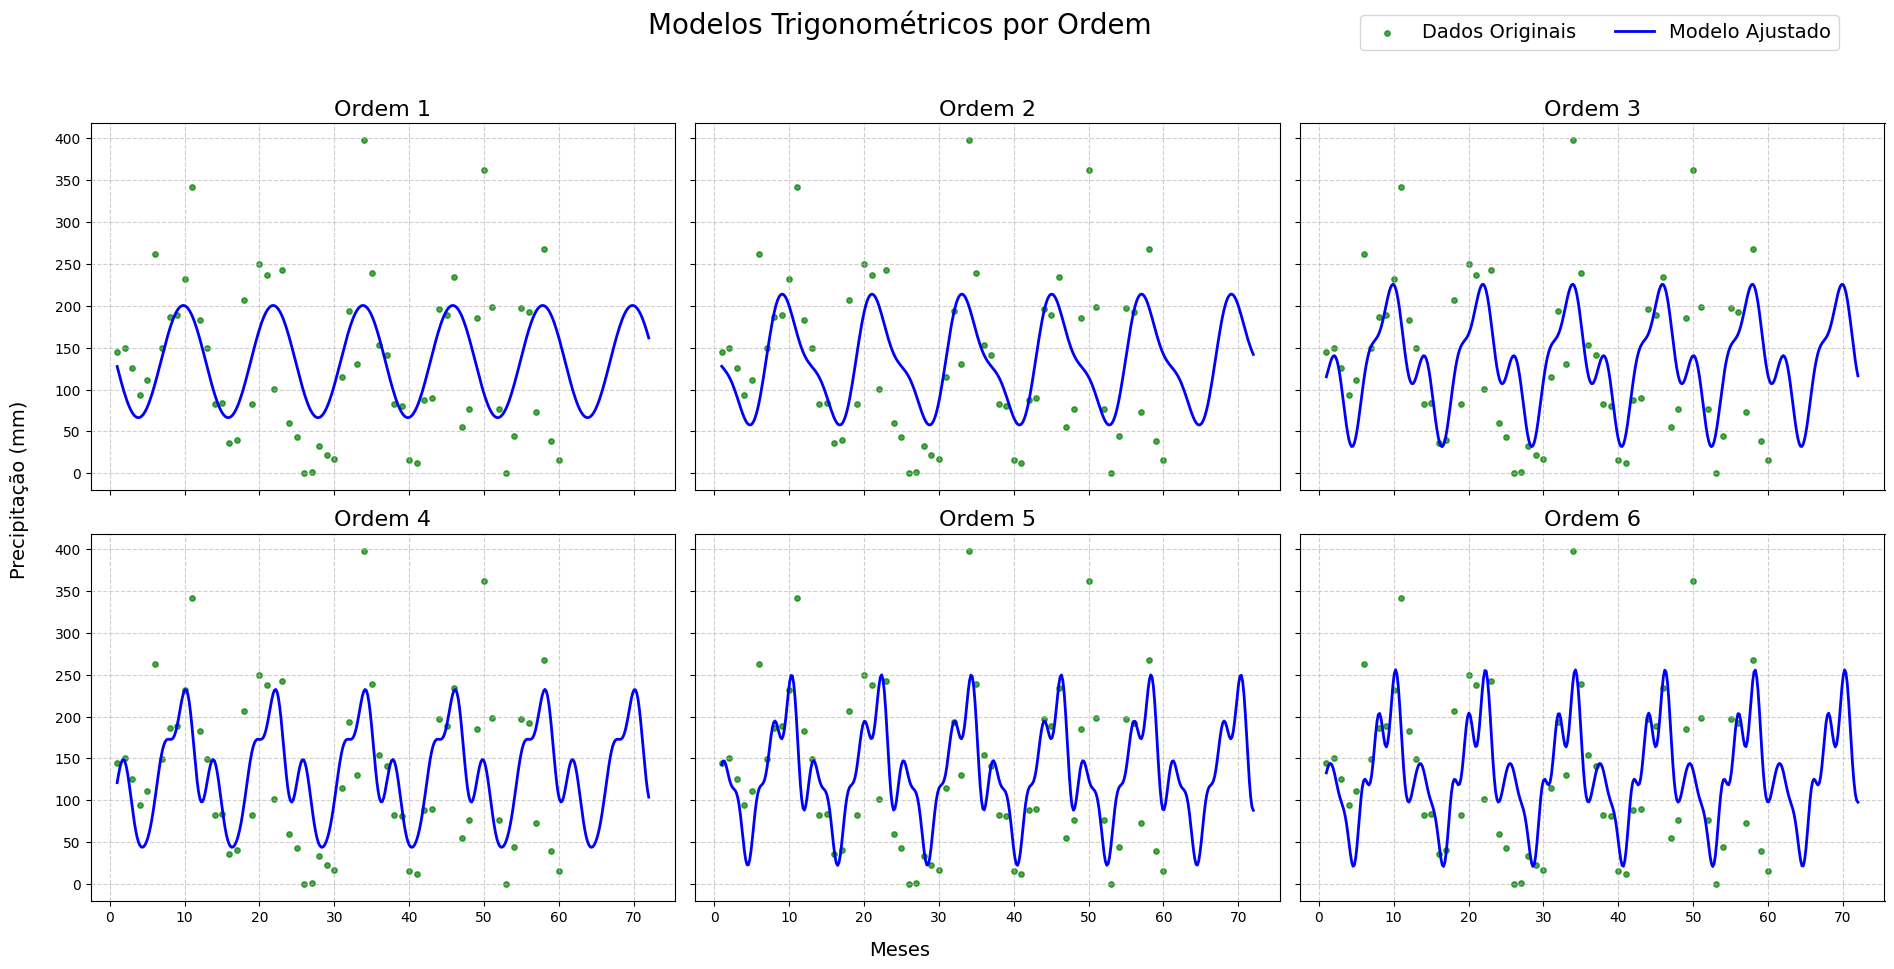

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Função de Modelo Trigonométrico Geral (a mesma de antes) ---
def modelo_trigonometrico_geral(x, *params):
    y = params[0]
    for k in range(1, len(params), 2):
        ordem_k = (k + 1) // 2
        Ak = params[k]
        Bk = params[k+1]
        y += Ak * np.cos(2 * np.pi * ordem_k * x / 12) + Bk * np.sin(2 * np.pi * ordem_k * x / 12)
    return y

# --- Estrutura Principal do Gráfico com Subplots ---

# 1. Criar uma figura e uma grade de eixos 2x3.
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# Adicionar um título principal para a figura inteira
fig.suptitle('Modelos Trigonométricos por Ordem', fontsize=20)

# 2. Loop para preencher cada subplot
for ordem in range(1, 7): # De 1 a 6
    row = (ordem - 1) // 3
    col = (ordem - 1) % 3
    ax = axs[row, col]

    num_params = 1 + 2 * ordem
    chute_inicial = [np.mean(y_dados)] + [0.0] * (2 * ordem)

    try:
        params_otimos, _ = curve_fit(modelo_trigonometrico_geral, x_dados, y_dados, p0=chute_inicial, maxfev=10000)
        x_curva = np.linspace(1, 72, 400)
        y_curva = modelo_trigonometrico_geral(x_curva, *params_otimos)
        
        # Plotar os dados e a curva com labels
        # Os labels serão usados para a legenda geral
        ax.scatter(x_dados, y_dados, color='green', alpha=0.7, s=15, label='Dados Originais')
        ax.plot(x_curva, y_curva, color='blue', linewidth=2, label='Modelo Ajustado')
        
        mes_futuro = 72
        precipitacao_prevista = modelo_trigonometrico_geral(mes_futuro, *params_otimos)
        print(f"Ordem {ordem}: Previsão para o mês 72 = {precipitacao_prevista:.2f} mm")
        
        ax.grid(True, linestyle='--', alpha=0.6)

        ax.set_title(f'Ordem {ordem}', fontsize=16)

    except RuntimeError:
        ax.set_title(f'Ordem {ordem} - Falha no Ajuste', color='red')
        print(f"Ordem {ordem}: Não foi possível ajustar o modelo.")

# 3. Adicionar rótulos comuns para a figura inteira
fig.text(0.5, 0.04, 'Meses', ha='center', va='center', fontsize=14)
fig.text(0.06, 0.5, 'Precipitação (mm)', ha='center', va='center', rotation='vertical', fontsize=14)

# 4. Criar a legenda geral
# Captura os "handles" (as linhas/pontos) e "labels" (os textos) de um dos subplots
# Como eles são os mesmos para todos os gráficos, podemos pegar de qualquer um (ex: axs[0,0])
handles, labels = axs[0,0].get_legend_handles_labels()

# Cria a legenda na figura, posicionada na parte inferior central, com 2 colunas
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.85, 0.93), ncol=2, fontsize=14)

# Ajustar o layout para evitar sobreposição
# O valor de 'bottom' em rect foi ajustado para dar espaço para a legenda
plt.tight_layout(rect=[0.07, 0.05, 1, 0.95]) 

plt.show()

--- Previsão com Spline Cúbica ---
A precipitação estimada para o mês 72 é: 411014.41 mm


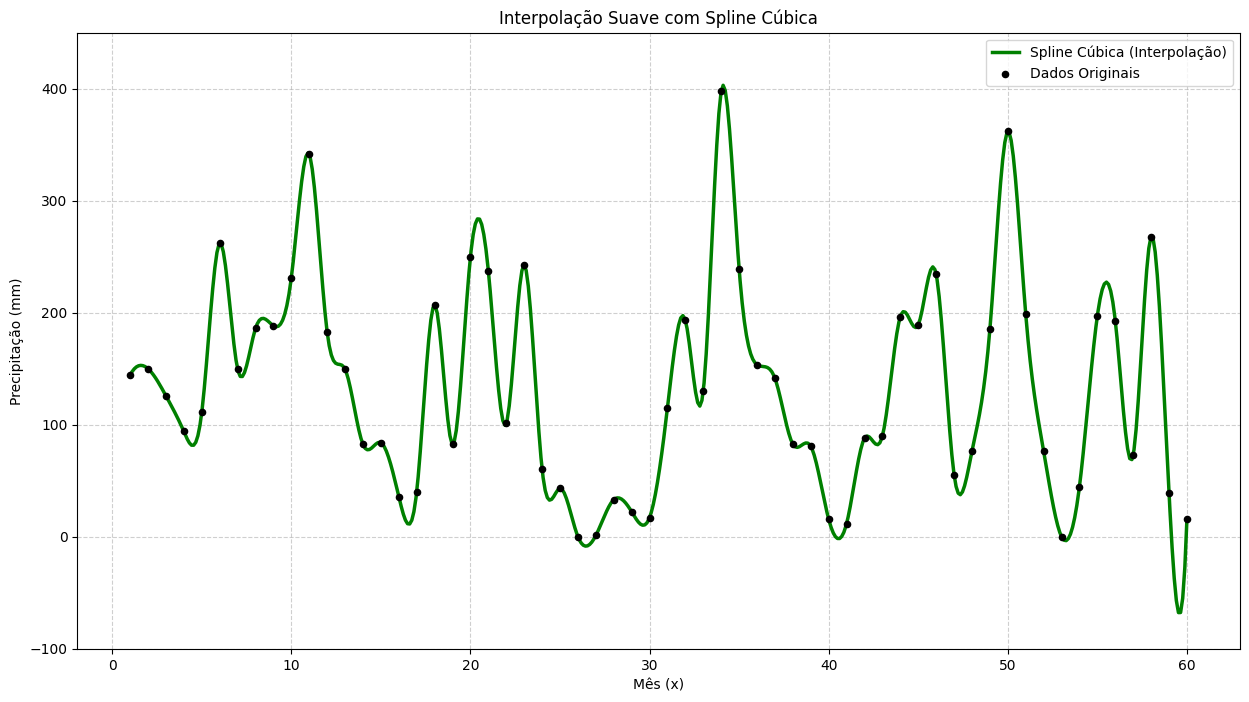

In [166]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Criando a função de Spline Cúbica ---
# A função é criada uma vez e pode ser usada para calcular qualquer ponto.
cs = CubicSpline(x_dados, y_dados)

# --- Previsão para o mês 72 (Extrapolação) ---
mes_futuro = 72
# A extrapolação usará o polinômio do último intervalo (entre os meses 59 e 60)
precipitacao_prevista = cs(mes_futuro)

print(f"--- Previsão com Spline Cúbica ---")
print(f"A precipitação estimada para o mês {mes_futuro} é: {precipitacao_prevista:.2f} mm")

# --- Visualização ---
plt.figure(figsize=(15, 8))

# Curva da Interpolação (dentro do intervalo 1-60)
x_interp = np.linspace(1, 60, 500)
y_interp = cs(x_interp)
plt.plot(x_interp, y_interp, label='Spline Cúbica (Interpolação)', color='green', linewidth=2.5)

# Curva da Extrapolação (depois do mês 60)
# x_extrap = np.linspace(60, 72, 100)
# y_extrap = cs(x_extrap)
# plt.plot(x_extrap, y_extrap, label='Extrapolação da Spline', color='red', linestyle='--')

# Dados originais
plt.scatter(x_dados, y_dados, label='Dados Originais', color='black', s=20, zorder=5)
plt.title('Interpolação Suave com Spline Cúbica')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.ylim(-100,450)
plt.show()

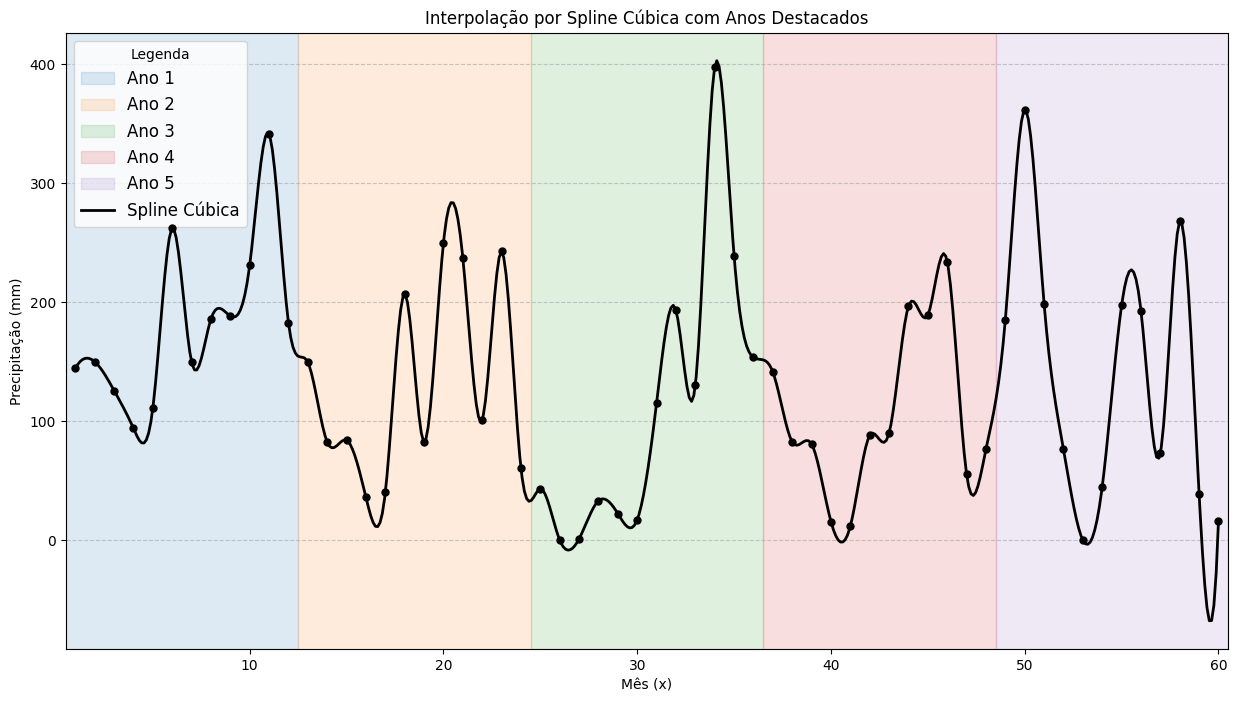

In [167]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# --- Seus dados ---
x_dados = np.arange(1, 61)
y_dados = np.array([
    144.4, 150.0, 125.8, 94.0, 111.0, 262.2, 149.8, 186.0, 188.4, 231.3,
    341.4, 182.7, 149.6, 82.4, 84.0, 35.9, 40.3, 207.0, 82.4, 250.0,
    237.2, 101.2, 242.7, 60.4, 43.2, 0.0, 1.1, 33.1, 22.3, 17.1,
    115.3, 193.2, 130.4, 397.8, 239.0, 153.6, 141.4, 82.6, 80.8, 15.6,
    11.8, 88.0, 90.0, 196.6, 189.2, 234.2, 55.4, 76.4, 185.4, 362.0,
    198.8, 76.4, 0.0, 44.8, 197.3, 192.8, 73.1, 268.0, 39.0, 15.8
])

# --- Passo 1: Criar a função de Spline Cúbica ---
# A função é criada uma vez e pode ser usada para calcular qualquer ponto.
cs = CubicSpline(x_dados, y_dados)

# --- Passo 2: Estrutura Principal do Gráfico ---
plt.figure(figsize=(15, 8))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Azul, Laranja, Verde, Vermelho, Roxo
numero_de_anos = 5

# Loop para sombrear o fundo de cada ano com faixas verticais
for ano in range(numero_de_anos):
    # O `axvspan` cria um retângulo vertical semi-transparente
    plt.axvspan(xmin=ano * 12 + 0.5, xmax=(ano + 1) * 12 + 0.5, 
                color=cores[ano], 
                alpha=0.15, # Baixa opacidade para dar o efeito de sombreamento
                label=f'Ano {ano + 1}') # O label será usado na legenda

# --- Passo 3: Plotar o modelo e os dados por cima do fundo ---

# Curva da Spline Cúbica (a linha principal)
x_curva = np.linspace(1, 60, 500)
y_curva = cs(x_curva)
plt.plot(x_curva, y_curva, color='black', label='Spline Cúbica', linewidth=2, zorder=10)

# Dados Originais (os pontos)
plt.scatter(x_dados, y_dados, color='black', s=25, zorder=11) # zorder alto para ficar na frente

# --- Passo 4: Configurações finais do gráfico ---
plt.title('Interpolação por Spline Cúbica com Anos Destacados')
plt.xlabel('Mês (x)')
plt.ylabel('Precipitação (mm)')
plt.xlim(0.5, 60.5) # Ajusta o limite do eixo X para ficar mais justo
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Legenda", fontsize=12)
plt.show()